In [1]:
from Bio import Align
from collections import Counter
import pandas as pd
import numpy as np
from collections import defaultdict
import csv
import json
import sqlite3
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import numpy as np
from copy import deepcopy


from src.set_costs import (
    set_cost,
    set_cost_two_way,
    set_cost_from_codes,
    set_cost_two_way_from_codes,
)
from src.levenshtein_c.levenshtein_cython import lde_similarity
from src.name_cleanup import value_to_cleaned_str
from src.count_confused_characters import (
    align_characters,
    pad_alignments,
    update_confusion_counter,
    counter_to_matrix,
)

# DB written sources/destinations to DB parishes

## Load data

In [2]:
database_path = Path("data/all_hiski_records.sqlite3")

table_cols = (
    "event_id",
    "dep_day", "dep_month", "dep_year",
    "arr_day", "arr_month", "arr_year",
    "destination/source", "village", "house",
    "profession", "first_name", "patronym", "last_name", "etc",
    "village_id", "parish_id",
    "destinationN/sourceN",
    "first_nameN", "patronymN", "last_nameN",
)


In [3]:
connection = sqlite3.connect(database_path)
cursor = connection.cursor()

In [4]:
db_pl_sources = cursor.execute("""
    SELECT source, sourceN, event_id, parish_id FROM immigrated;
    """).fetchall()
db_pl_destinations = cursor.execute("""
    SELECT destination, destinationN, event_id, parish_id FROM emigrated;
    """).fetchall()

db_pl_cleaned_idx_names = [
    "source/destination",
    "sourceN/destinationN",
    "event_id",
    "parish_id",
]

db_pl_sources_cleaned = []
for i, name in enumerate(db_pl_sources):
    if (cleaned_name := value_to_cleaned_str(name[0])) == "":
        continue
    db_pl_sources_cleaned.append((cleaned_name, name[2], name[3]))

db_pl_destinations_cleaned = []
for i, name in enumerate(db_pl_destinations):
    if (cleaned_name := value_to_cleaned_str(name[0])) == "":
        continue
    db_pl_destinations_cleaned.append((cleaned_name, name[2], name[3]))

In [5]:
cursor.execute("SELECT * FROM parish;")
parish_data = cursor.fetchall()

In [6]:
db_places_new_df = pd.read_csv("data/csv/places_from_new_db.tsv", sep="\t", na_values="\\N", header=0)
db_places_new_df = db_places_new_df.fillna("")
db_places_new = db_places_new_df.to_dict("list")

In [7]:
parish_data_new = {
    "pl_id": db_places_new["pl_id"],
    "pl_name": db_places_new["pl_name"],
    "pl_namn": db_places_new["pl_namn"],
}
parish_data_new["pl_name"] = list(map(str, parish_data_new["pl_name"]))
parish_data_new["pl_namn"] = list(map(str, parish_data_new["pl_namn"]))

db_unique_places_both = {"pl_id": [], "pl_name": [], "pl_namn": []}

for i in range(len(parish_data)):
    if parish_data[i][0] in db_unique_places_both["pl_id"]:
        continue

    db_unique_places_both["pl_id"].append(parish_data[i][0])
    db_unique_places_both["pl_name"].append(parish_data[i][2])
    db_unique_places_both["pl_namn"].append(parish_data[i][3])

for i in range(len(parish_data_new)):
    if parish_data_new["pl_id"][i] in db_unique_places_both["pl_id"]:
        continue

    db_unique_places_both["pl_id"].append(parish_data_new["pl_id"][0])
    db_unique_places_both["pl_name"].append(parish_data_new["pl_name"][2])
    db_unique_places_both["pl_namn"].append(parish_data_new["pl_namn"][3])

## DB parishes/places to DB written sources/destinations

### Set weights

In [8]:
size = 256

consonants = "bcdfghjklmnpqrstvwxz"
consonants_upper = consonants.upper()
consonants_both_cases = consonants + consonants_upper
vowels = "aeiouyäöå"
vowels_upper = vowels.upper()
vowels_both_cases = vowels + vowels_upper
all = consonants_both_cases + vowels_both_cases
vowel_codes = [ord(c) for c in vowels]
vowel_upper_codes = [ord(c) for c in vowels_upper]
consonant_codes = [ord(c) for c in consonants]
consonant_upper_codes = [ord(c) for c in consonants_upper]
all_codes = (
    vowel_codes + vowel_upper_codes + consonant_codes + consonant_upper_codes
)

punctuation_codes = (ord("."), ord("?"))
colon_code = (ord(":"),)

In [9]:
insert_costs = np.full(size, fill_value=2.0, dtype=np.float64)

delete_costs = np.ones(size, dtype=np.float64)
set_cost(delete_costs, 4.0, ".")
set_cost(delete_costs, 0.0, "?")
set_cost(delete_costs, 4.0, ":")

In [10]:
substitute_costs = np.ones((size, size), dtype=np.float64)

set_cost_two_way_from_codes(substitute_costs, 4.0, all_codes, colon_code)
set_cost_two_way_from_codes(substitute_costs, 4.0, all_codes, punctuation_codes)

# vowel-vowel substitute costs
set_cost_from_codes(substitute_costs, 1.0, vowel_codes, vowel_codes)
set_cost_from_codes(substitute_costs, 2.0, vowel_upper_codes, vowel_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, vowel_upper_codes)

# consonant-consonant substitute costs
set_cost_from_codes(substitute_costs, 2.0, consonant_codes, consonant_codes)
set_cost_from_codes(substitute_costs, 4.0, consonant_upper_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 6.0, consonant_codes, consonant_upper_codes)

# vowel-consonant substitute costs
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, consonant_codes)
set_cost_two_way_from_codes(substitute_costs, 3.0, vowel_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 6.0, vowel_upper_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 9.0, vowel_codes, consonant_upper_codes)
set_cost_two_way_from_codes(substitute_costs, 9.0, vowel_upper_codes, consonant_codes)

# remove possible substitute cost for self
substitute_costs[np.diag_indices(256)] = len(substitute_costs.diagonal()) * [0]

In [11]:
pair_specific_sub_costs = (
    (0.65, "o", "a"),
    (0.0 , "k", "c"),
    (0.6, "i", "e"),
    (0.7, "e", "i"),
    (0.25, "d", "j"),
    (0.75, "i", "j"),
    (0.15, "g", "k"),
    (0.15, "å", "o"),
    (0.15, "b", "p"),
    (0.15, "d", "t"),
    (0.35, "o", "u"),
    (0.3, "w", "v"),
    (0.0 , "k", "x"),
    (0.25, "e", "ä"),
    (0.05, "o", "å")
)

In [12]:
for p in pair_specific_sub_costs:
    set_cost_two_way(substitute_costs, p[0], p[1], p[2])

In [13]:
deabbreviate_costs = {}

deabbreviate_costs[":"] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs[":"], 0.25, vowel_codes + consonant_codes)

deabbreviate_costs["."] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs["."], 2.0, vowel_codes + consonant_codes)

deabbreviate_costs["?"] = np.full(256, 100.0)
set_cost_from_codes(deabbreviate_costs["?"], 2.0, vowel_codes + consonant_codes)

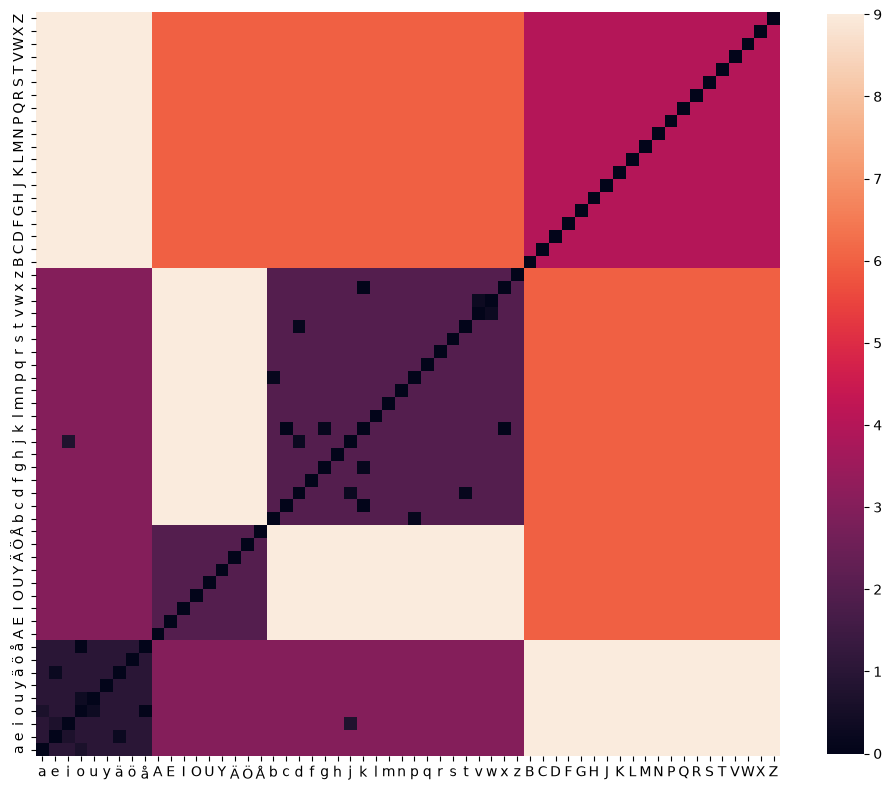

In [14]:
fig, axs = plt.subplots(1, 1, figsize=(12, 12))
ax = sns.heatmap(
    substitute_costs[all_codes][:, all_codes],
    xticklabels=list(map(chr, all_codes)),
    yticklabels=list(map(chr, all_codes)),
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.invert_yaxis()

### Find matches

In [15]:
def best_match(
        query, choices,
        substitute_costs, insert_costs, delete_costs,
        deabbreviate_costs, deabbreviate_penalty, deabbreviate_max_len,
):
    best_idx = -1
    #best_score = -np.inf
    best_score = -10000
    for idx, option in enumerate(choices):
        if len(option) == 0:
            score = best_score
        elif substitute_costs[ord(query[0]), ord(option[0])] > 2.0:
            score = best_score
        else:
            score = lde_similarity(
                query,
                option,
                substitute_costs,
                insert_costs,
                delete_costs,
                deabbreviate_costs,
                deabbreviate_penalty,
                deabbreviate_max_len
            ) * 100

        if score > best_score:
            best_score = score
            best_idx = idx

    return best_idx, best_score

In [16]:
db_pl_unique_matches = {}
db_pl_unique_no_matches = {}
score_cutoff = 40
db_unique_place_ids = db_unique_places_both["pl_id"]
db_unique_place_names_fi = db_unique_places_both["pl_name"]
db_unique_place_names_se = db_unique_places_both["pl_namn"]

for pl in tqdm(set(tuple(x[0] for x in db_pl_sources_cleaned + db_pl_destinations_cleaned))):
    idx_fi, score_fi = best_match(
        pl,
        db_unique_place_names_fi,
        substitute_costs=substitute_costs,
        insert_costs=insert_costs,
        delete_costs=delete_costs,
        deabbreviate_costs=deabbreviate_costs,
        deabbreviate_penalty=1.0,
        deabbreviate_max_len=4
    )

    idx_se, score_se = best_match(
        pl,
        db_unique_place_names_se,
        substitute_costs=substitute_costs,
        insert_costs=insert_costs,
        delete_costs=delete_costs,
        deabbreviate_costs=deabbreviate_costs,
        deabbreviate_penalty=1.0,
        deabbreviate_max_len=4
    )

    if score_fi >= score_se:
        lang, idx, score = "fi", idx_fi, score_fi
    else:
        lang, idx, score = "se", idx_se, score_se

    if score < score_cutoff:
        db_pl_unique_no_matches[pl] = {
            "name_fi": None,
            "name_se": None,
            "proposed_language": None,
            "score": None,
            "pl_id": db_unique_place_ids[idx],
        }
        continue

    db_pl_unique_matches[pl] = {
        "name_fi": db_unique_place_names_fi[idx],
        "name_se": db_unique_place_names_se[idx],
        "proposed_language": lang,
        "score": score,
        "pl_id": db_unique_place_ids[idx],
    }

  0%|          | 0/24304 [00:00<?, ?it/s]

### Create data

#### JSONs

In [17]:
db_pl_data_non_unique = defaultdict(list)
for place_spelling in (db_pl_sources_cleaned + db_pl_destinations_cleaned):
    name_spelling = place_spelling[0]
    actual = db_pl_unique_matches.get(name_spelling, None)
    if actual:
        if actual["proposed_language"] == "fi":
            db_pl_data_non_unique[actual["name_fi"]].append(
                (name_spelling, actual["score"], "fi")
            )
        else:
            db_pl_data_non_unique[actual["name_se"]].append(
                (name_spelling, actual["score"], "se")
            )

In [18]:
db_pl_data_unique = {}
for actual_name, place_spellings in db_pl_data_non_unique.items():
    db_pl_data_unique[actual_name] = list(set(
        place_spellings
    ))

In [19]:
db_pl_data_unique_with_counts = defaultdict(Counter)
for actual_name, place_spellings in db_pl_data_non_unique.items():
    db_pl_data_unique_with_counts[actual_name].update(
        place_spellings
    )

In [20]:
threshold = 85.0

In [21]:
db_pl_data_non_unique_thresholded = {}
for place, spellings in db_pl_data_non_unique.items():
    db_pl_data_non_unique_thresholded[place] = tuple(
        filter(lambda x: x[1] >= 85.0, spellings)
    )

In [22]:
db_pl_data_unique_thresholded = {}
for place, spellings in db_pl_data_unique.items():
    db_pl_data_unique_thresholded[place] = tuple(
        filter(lambda x: x[1] >= 85.0, spellings)
    )

In [23]:
db_pl_data_unique_with_counts_thresholded = {}
for place, spellings in db_pl_data_unique_thresholded.items():
    db_pl_data_unique_with_counts_thresholded[place] = tuple(
        s + (db_pl_data_unique_with_counts[place][s],) for s in spellings
    )

#### Dataset

In [24]:
dataset = []
for place, spellings in db_pl_data_non_unique_thresholded.items():
    dataset += tuple(
        (spelling[0], place, spelling[1])
        for spelling in spellings if spelling[0] != place
    )

### Output

In [25]:
def format_json(data, indent=4):
    def format_list(lst, level):
        items = ", ".join(json.dumps(x, ensure_ascii=False) for x in lst)
        return f"[{items}]"

    lines = ["{"]
    keys = list(data.keys())
    for i, key in enumerate(keys):
        key_str = json.dumps(key, ensure_ascii=False)
        lines.append(f'{" " * indent}{key_str}: [')
        entries = data[key]
        for j, entry in enumerate(entries):
            comma = "," if j < len(entries) - 1 else ""
            lines.append(f'{" " * indent * 2}{format_list(entry, 2)}{comma}')
        comma = "," if i < len(keys) - 1 else ""
        lines.append(f'{" " * indent}]{comma}')
    lines.append("}")
    return "\n".join(lines)

In [26]:
with open("outputs/json/db_places_spellings.json", "w") as fp:
    fp.write(format_json(db_pl_data_unique))

with open("outputs/json/db_places_spellings_thresholded.json", "w") as fp:
    fp.write(format_json(db_pl_data_unique_thresholded))

with open("outputs/json/db_places_spellings_with_counts_thresholded.json", "w") as fp:
    fp.write(format_json(db_pl_data_unique_with_counts_thresholded))

with open("outputs/csv/db_places_spellings_dataset.csv", "w") as fp:
    csv.writer(fp, quotechar='\"', quoting=2).writerows(
        dataset
    )

## Analyzing which characters get mixed up

In [27]:
place_spellings_data = db_pl_data_non_unique_thresholded

In [28]:
aligner = Align.PairwiseAligner(mode="global")

In [29]:
confusion_counter = defaultdict(Counter)

In [30]:
gathered_alignments = {}
for place, spellings in place_spellings_data.items():
    place_spellings = tuple(list(pl[0]) for pl in spellings)

    if len(place_spellings) == 0:
        continue

    place_alignments, spelling_alignments = align_characters(place, place_spellings, aligner)
    place_alignments, spelling_alignments = pad_alignments(place_alignments, spelling_alignments)

    update_confusion_counter(
        confusion_counter,
        zip(place_alignments, spelling_alignments),
    )
    
    gathered_alignments[place] = list(zip(place_alignments, spelling_alignments))


confusion_counter_exclude_self = deepcopy(confusion_counter)
for character, character_counter in confusion_counter_exclude_self.items():
    del character_counter[character]

In [31]:
for place, alignments in gathered_alignments.items():
    for i, pair in enumerate(alignments):
        pair = (
            "".join([c or "_" for c in pair[0]]),
            "".join([c or "_" for c in pair[1]])
        )
        gathered_alignments[place][i] = pair

In [32]:
unique_alignments = []
for place, alignments in gathered_alignments.items():
    unique_alignments += set(alignments)

unique_alignments_df = pd.DataFrame(unique_alignments)

In [33]:
def create_barplots(confusion_counter, chars, rows, cols, size):
    fig, axs = plt.subplots(rows, cols, figsize=size, sharey=True)

    for ax in axs:
        ax[0].set_ylabel(f"Portion out of total")

    for i, ax in enumerate(axs.flat):
        if i >= len(chars):
            break
        char = chars[i]
        sns.barplot(
            {c: count / confusion_counter[char].total() for c, count in confusion_counter[char].most_common(3)},
            ax=ax,
        )
        ax.set_yticks(tuple(i*0.1 for i in range(0, 11, 1)))
        ax.set_title(f"{char}, total: {confusion_counter[char].total()}")
        ax.set_xlabel(f"character written instead of '{char}'")

    plt.tight_layout()

In [34]:
def create_heatmap(matrix, chars, ax):
    sns.heatmap(
        matrix,
        xticklabels=chars,
        yticklabels=chars,
        square=True,
        vmin=0,
        vmax=1,
        cbar_kws={"shrink": 0.6},
        ax=ax,
    )
    ax.tick_params(
        labelbottom=True,
        labeltop=True,
        labelleft=True,
        labelright=True,
        bottom=True,
        top=True,
        left=True,
        right=True,
    )
    ax.set_ylabel("actual")
    ax.set_xlabel("written")
    ax.invert_yaxis()
    ax.set_title("Confused characters")


def create_heatmaps(
    confusion_counter, confusion_counter_exclude_self, chars, size
):
    fig, axs = plt.subplots(1, 2, figsize=size)

    matrix = counter_to_matrix(chars, confusion_counter, True)
    create_heatmap(matrix, chars, axs[0])
    matrix_exclude_self = counter_to_matrix(
        chars, confusion_counter_exclude_self, True
    )
    create_heatmap(matrix_exclude_self, chars, axs[1])

    fig.tight_layout()

Inspecting lowercase letters

In [35]:
chars = sorted(vowels + consonants)

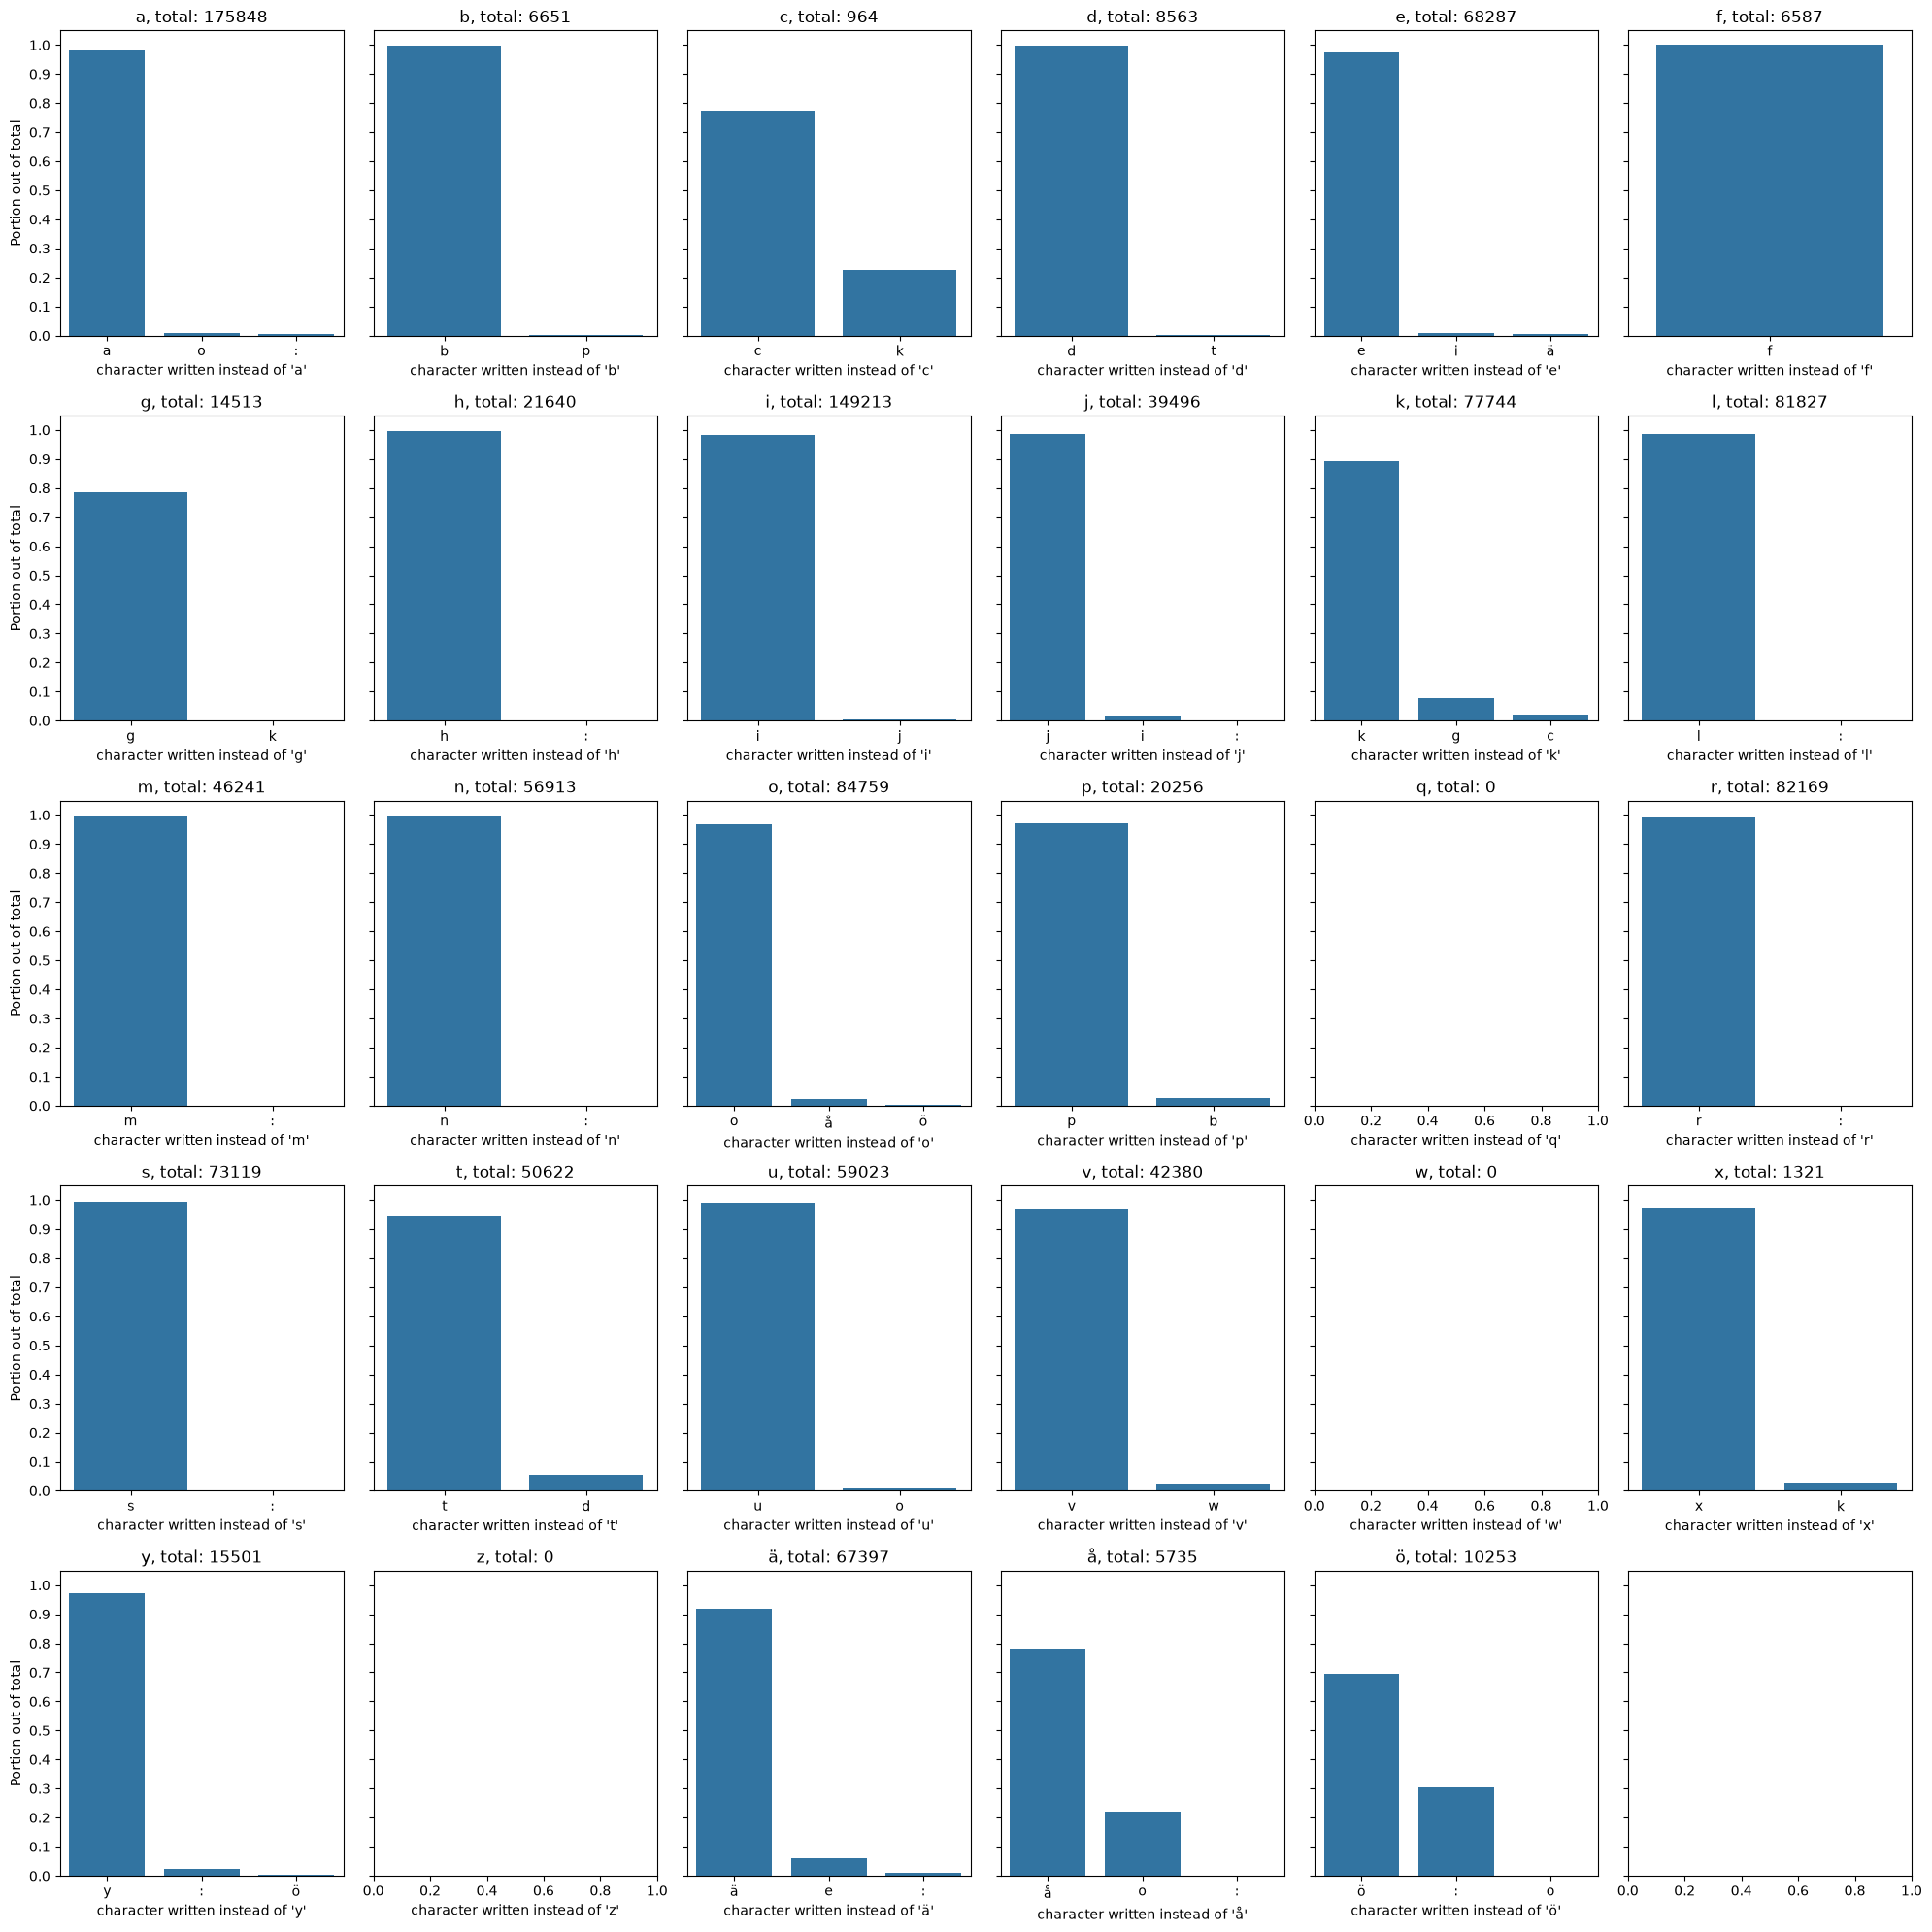

In [36]:
create_barplots(confusion_counter, chars, 5, 6, (20, 20))

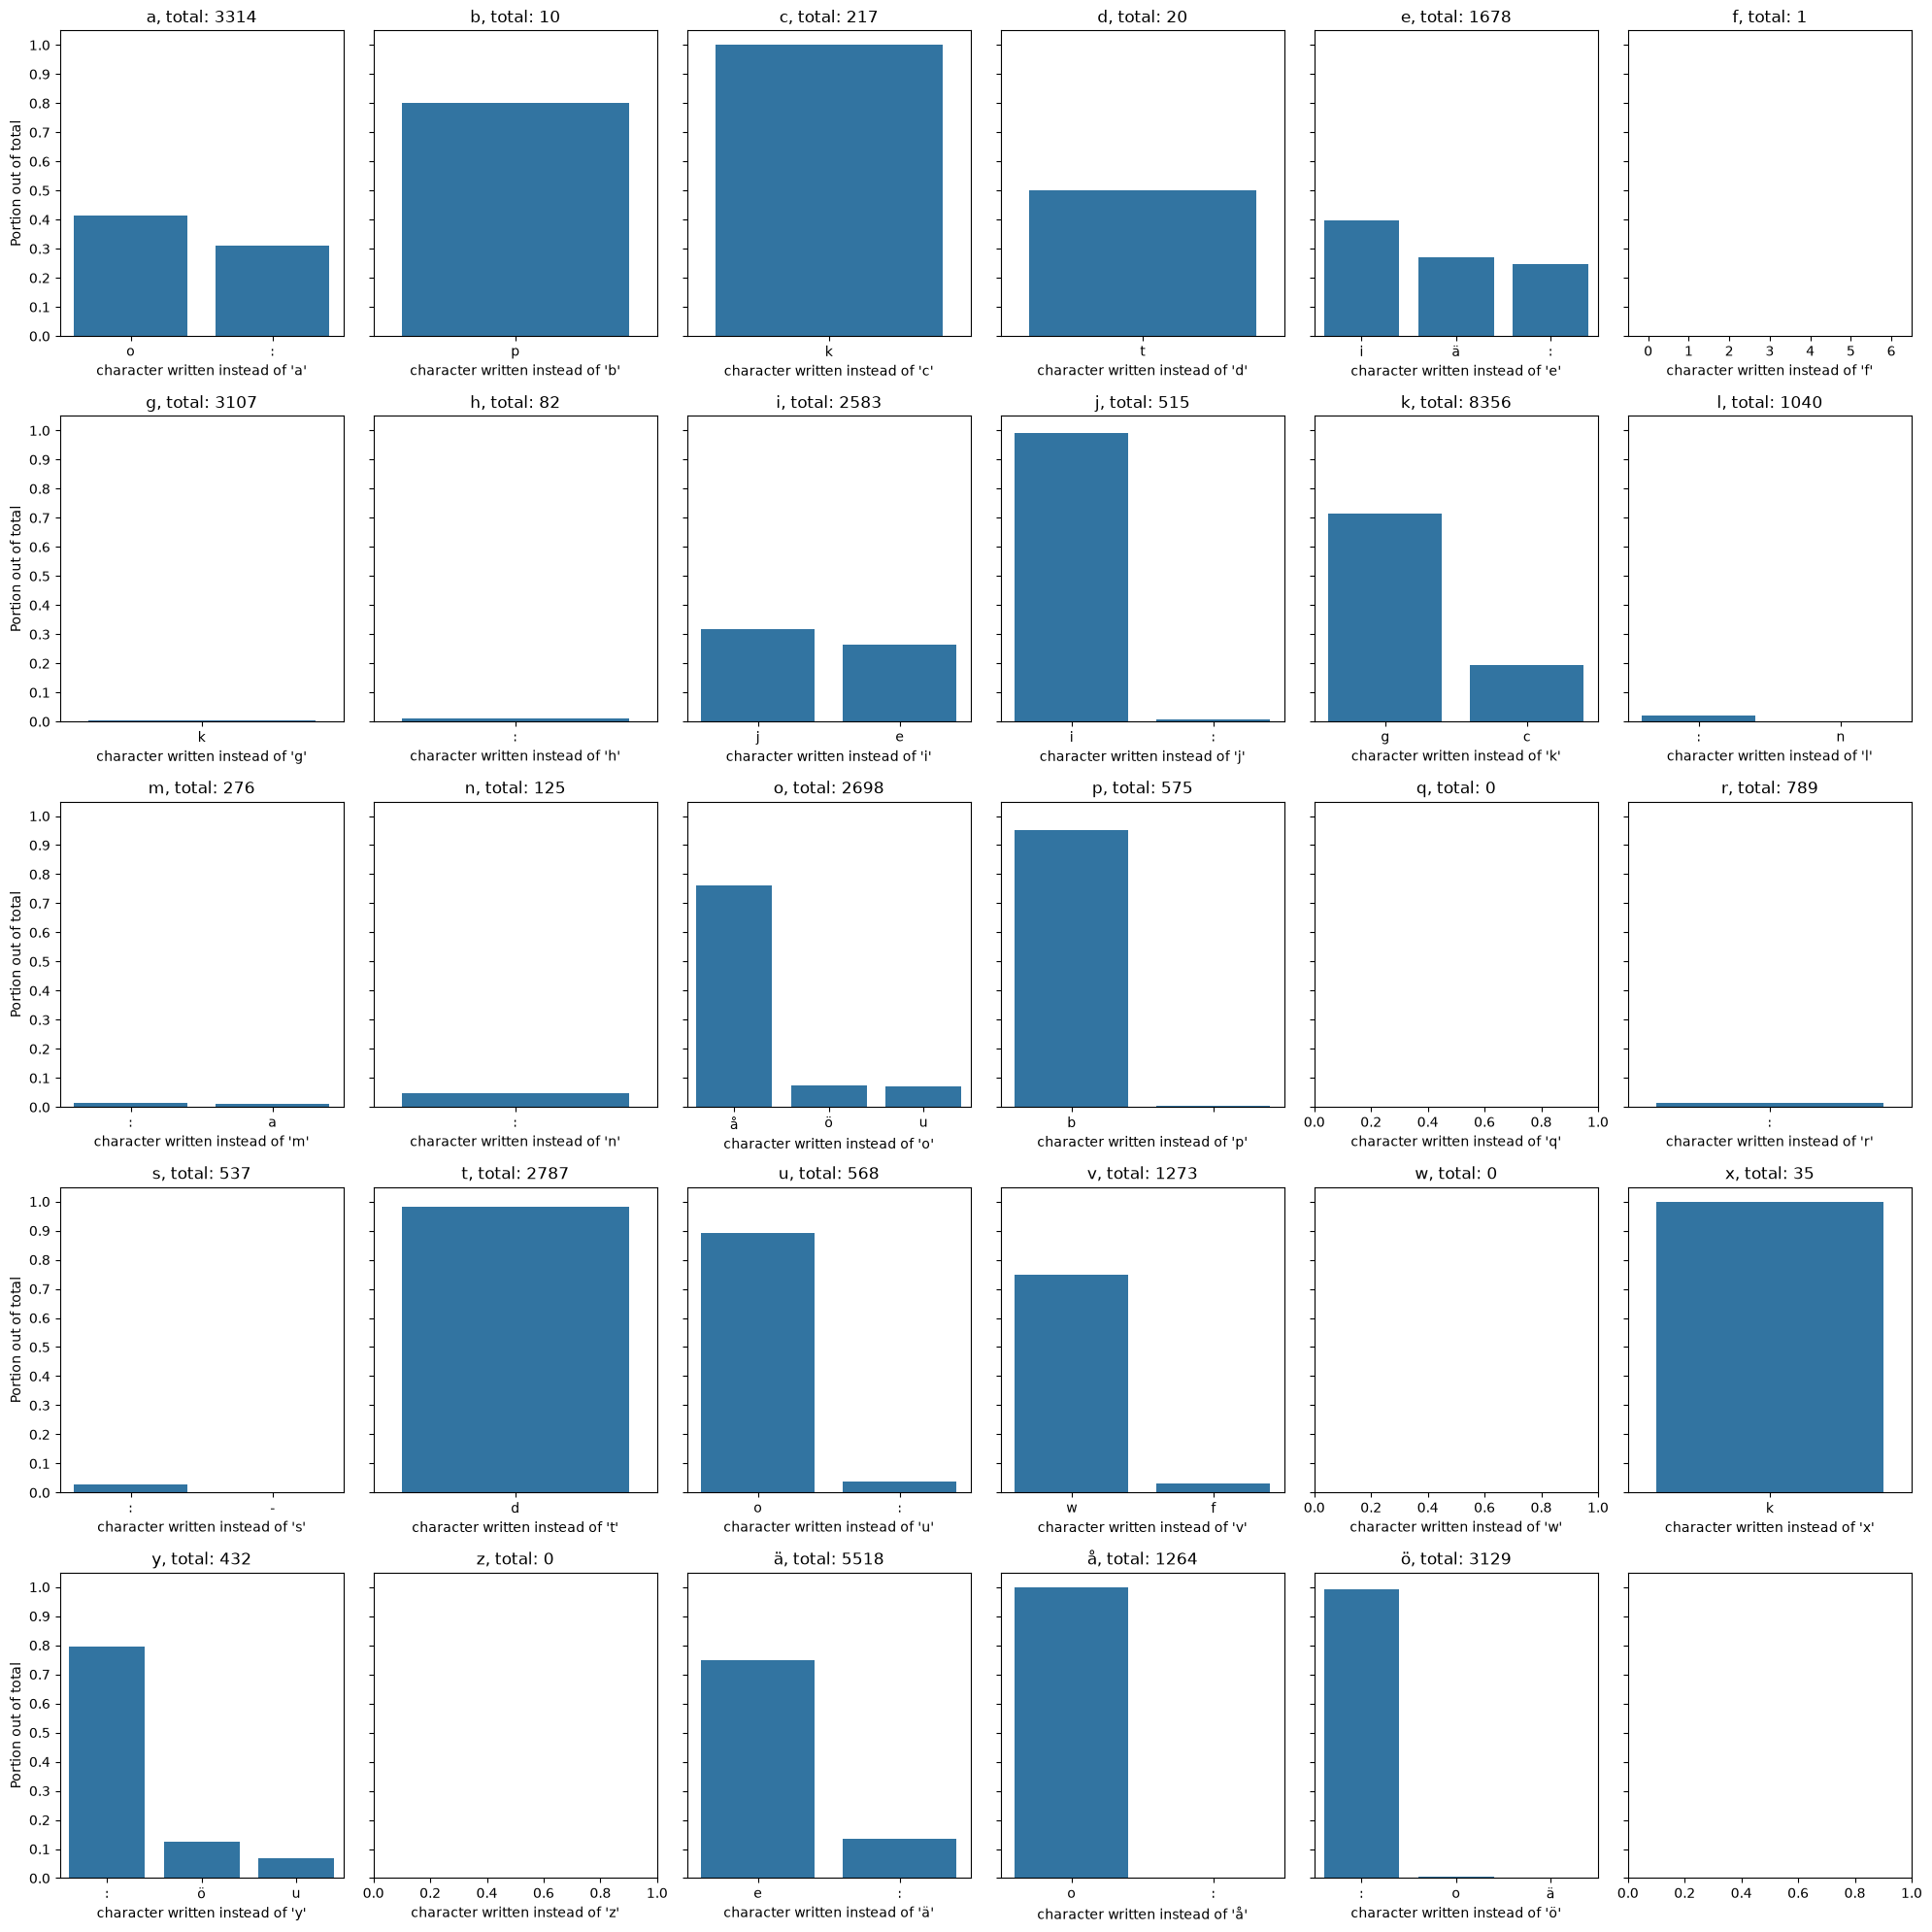

In [37]:
create_barplots(confusion_counter_exclude_self, chars, 5, 6, (20, 20))

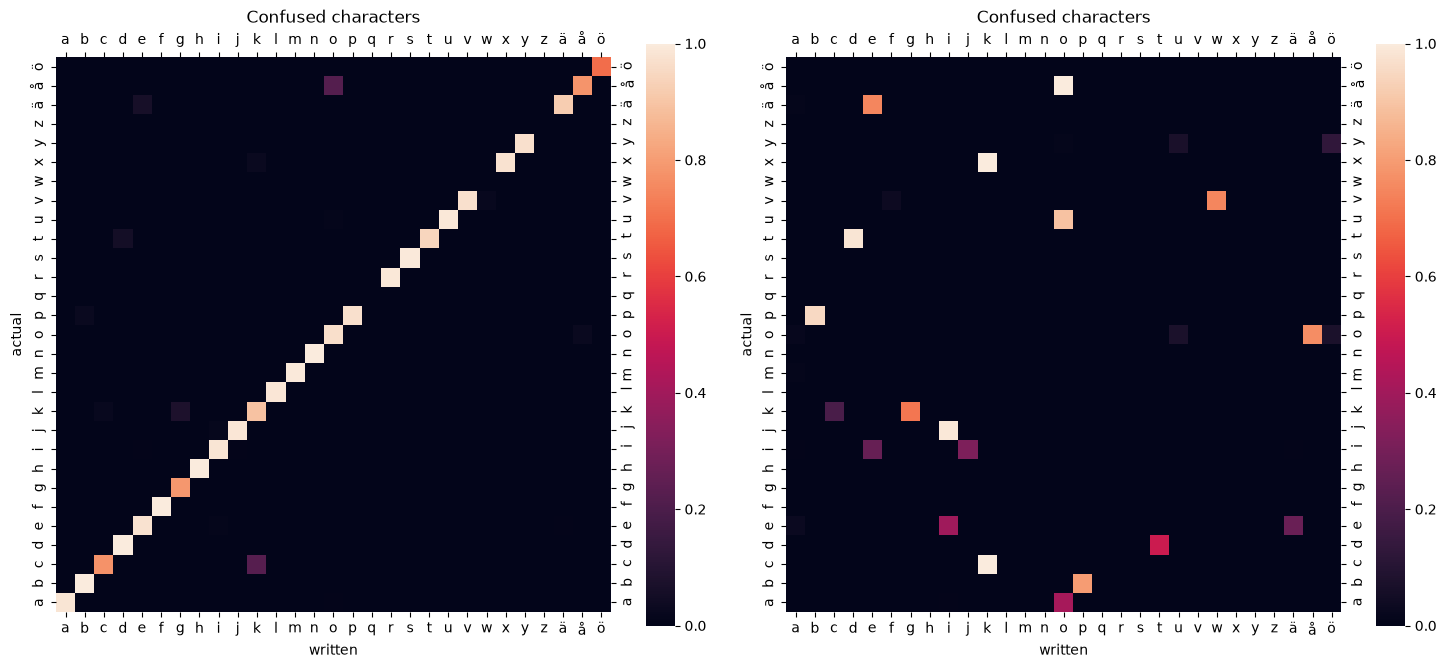

In [38]:
create_heatmaps(confusion_counter, confusion_counter_exclude_self, chars, (15, 10))

In [39]:
threshold = 0.25

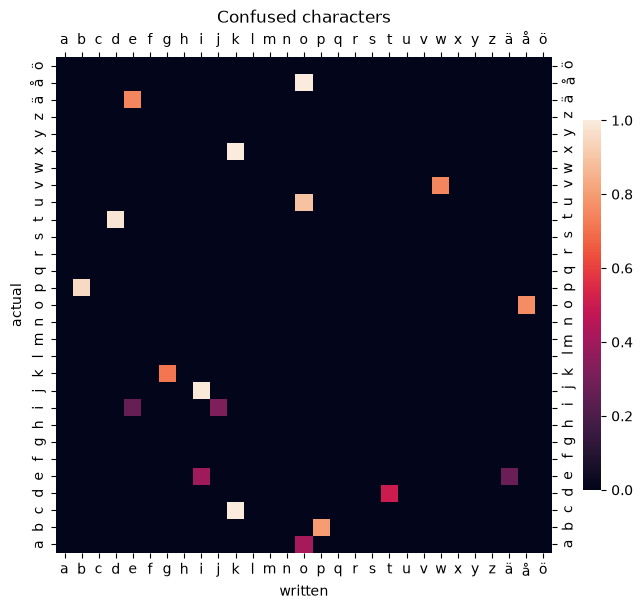

In [40]:
fig, axs = plt.subplots(figsize=(8, 8))
matrix = counter_to_matrix(chars, confusion_counter_exclude_self, True)
matrix = matrix * (matrix >= threshold)
create_heatmap(matrix, chars, ax=axs)

According to the character confusion counts the following kind of character weights should be set:


In [41]:
for c1, c2 in np.column_stack(np.nonzero(matrix * (matrix > threshold))):
    print(chars[c2], chars[c1], round(1 - matrix[c1, c2], 2))

o a 0.59
p b 0.2
k c 0.0
t d 0.5
i e 0.6
ä e 0.73
e i 0.74
j i 0.68
i j 0.01
g k 0.29
å o 0.24
b p 0.05
d t 0.02
o u 0.11
w v 0.25
k x 0.0
e ä 0.25
o å 0.0
